In [1]:
# ====================================================================
# SECTION 1: ENVIRONMENT SETUP AND REPRODUCIBILITY
# ====================================================================

# Standard libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Scikit-learn: Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Scikit-learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: Model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix, roc_curve, auc,
    classification_report, ConfusionMatrixDisplay
)

# Model persistence
import joblib
from pathlib import Path

# ====================================================================
# REPRODUCIBILITY SETTINGS
# ====================================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Define file paths
PROJECT_DIR = Path('..').resolve()  # Parent directory
DATA_DIR = PROJECT_DIR / 'data'
MODEL_DIR = PROJECT_DIR / 'model'
RESULTS_DIR = PROJECT_DIR / 'results'

# Create directories if they don't exist
RESULTS_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print("✓ Environment setup complete")
print(f"✓ Project directory: {PROJECT_DIR}")
print(f"✓ Random state: {RANDOM_STATE}")

✓ Environment setup complete
✓ Project directory: C:\ml assignment\telco-customer-churn
✓ Random state: 42


In [2]:
# ====================================================================
# SECTION 2: LOAD DATASET FROM LOCAL CSV
# ====================================================================

# TODO: Download the dataset from Kaggle and place in data/ directory
# Download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
# File name: WA_Fn-UseC_-Telco-Customer-Churn.csv

# For this example, we'll create a sample dataset structure
# In production, replace with actual CSV path

CSV_PATH = DATA_DIR / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Check if file exists
if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"✓ Dataset loaded successfully: {CSV_PATH}")
    print(f"✓ Dataset shape: {df.shape}")
    print(f"\nFirst 5 rows:")
    print(df.head())
else:
    print(f"⚠ Dataset not found at: {CSV_PATH}")
    print("Please download the dataset from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn")
    print("and place it in the data/ directory with the filename: WA_Fn-UseC_-Telco-Customer-Churn.csv")

✓ Dataset loaded successfully: C:\ml assignment\telco-customer-churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv
✓ Dataset shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...      

## Section 2: Load Dataset from Local CSV

In [3]:
# ====================================================================
# SECTION 3: SCHEMA INSPECTION AND DATA QUALITY CHECKS
# ====================================================================

print("="*70)
print("DATA QUALITY INSPECTION")
print("="*70)

# Dataset Information
print(f"\n1. Dataset Dimensions:")
print(f"   Shape: {df.shape}")
print(f"   Rows (instances): {df.shape[0]}")
print(f"   Columns (features): {df.shape[1]}")

# Column Information
print(f"\n2. Column Names and Data Types:")
print(df.dtypes)

# Missing Values
print(f"\n3. Missing Values:")
missing_data = df.isnull().sum()
if missing_data.sum() == 0:
    print("   No missing values detected")
else:
    print(missing_data[missing_data > 0])

# Duplicate Rows
print(f"\n4. Duplicate Rows:")
duplicates = df.duplicated().sum()
print(f"   Total duplicates: {duplicates}")

# Target Variable Distribution
print(f"\n5. Target Variable Distribution (Churn):")
if 'Churn' in df.columns:
    churn_dist = df['Churn'].value_counts()
    print(churn_dist)
    churn_pct = df['Churn'].value_counts(normalize=True) * 100
    print(f"\nPercentage distribution:")
    print(churn_pct)
    
    # Visualize target distribution
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    churn_dist.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_title('Churn Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Churn')
    ax.set_ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("   Target column 'Churn' not found in dataset")

print("\n" + "="*70)

DATA QUALITY INSPECTION

1. Dataset Dimensions:
   Shape: (7043, 21)
   Rows (instances): 7043
   Columns (features): 21

2. Column Names and Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

3. Missing Values:
   No missing values detected

4. Duplicate Rows:
   Total duplicates: 0

5. Target Variable Distribution (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage distribution:
Churn
No     73.463013
Yes 

<Figure size 800x500 with 1 Axes>

## Section 3: Schema Inspection and Data Quality Checks

In [4]:
# ====================================================================
# SECTION 4: TARGET ENCODING AND FEATURE CLEANUP
# ====================================================================

print("Data preprocessing started...\n")

# Step 1: Remove customerID (identifier, not predictive)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("✓ Removed 'customerID' column")

# Step 2: Convert TotalCharges to numeric
# Original dataset may contain blank/string values
if 'TotalCharges' in df.columns:
    # Coerce to numeric, replacing non-numeric with NaN
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print(f"✓ Converted 'TotalCharges' to numeric")
    print(f"  Missing values after conversion: {df['TotalCharges'].isnull().sum()}")
    
    # Handle missing TotalCharges values
    # Strategy: Impute with median during preprocessing (not here)
    # For now, note them
    if df['TotalCharges'].isnull().sum() > 0:
        print(f"  Note: Missing TotalCharges will be imputed in preprocessing pipeline")

# Step 3: Encode target variable
# No → 0, Yes → 1
if 'Churn' in df.columns:
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
    print(f"✓ Encoded target 'Churn': No=0, Yes=1")
    print(f"  Target distribution:")
    print(f"    Class 0 (No Churn): {(df['Churn'] == 0).sum()}")
    print(f"    Class 1 (Churn): {(df['Churn'] == 1).sum()}")
    
print(f"\n✓ Preprocessing preparation complete")
print(f"✓ Dataset shape after cleanup: {df.shape}")

Data preprocessing started...

✓ Removed 'customerID' column
✓ Converted 'TotalCharges' to numeric
  Missing values after conversion: 11
  Note: Missing TotalCharges will be imputed in preprocessing pipeline
✓ Encoded target 'Churn': No=0, Yes=1
  Target distribution:
    Class 0 (No Churn): 5174
    Class 1 (Churn): 1869

✓ Preprocessing preparation complete
✓ Dataset shape after cleanup: (7043, 20)


## Section 4: Target Encoding and Feature Cleanup

In [5]:
# ====================================================================
# SECTION 5: PREPROCESSING STRATEGY WITH COLUMNTRANSFORMER
# ====================================================================

# Separate features (X) and target (y)
if 'Churn' in df.columns:
    X = df.drop('Churn', axis=1)
    y = df['Churn']
    print(f"✓ Separated features (X) and target (y)")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")
else:
    print("Error: 'Churn' column not found")

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n✓ Feature separation complete:")
print(f"  Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")

# ====================================================================
# BUILD PREPROCESSING PIPELINE
# ====================================================================

# Numerical pipeline: Imputation + Scaling
# (Missing values in TotalCharges will be handled by imputer)
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())  # Scale features for distance-based models
])

# Categorical pipeline: Imputation + Encoding
# OneHotEncoder with sparse_output=False for GaussianNB compatibility
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))  # Handle unseen categories
])

# Combine both pipelines using ColumnTransformer
# This prevents data leakage by fitting transformers only on training data
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_pipeline, numerical_features),
        ('categorical', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)

print(f"\n✓ Preprocessing pipeline created:")
print(f"  Numerical: SimpleImputer + StandardScaler")
print(f"  Categorical: SimpleImputer + OneHotEncoder (sparse=False)")
print(f"  Strategy: ColumnTransformer to prevent data leakage")

✓ Separated features (X) and target (y)
  X shape: (7043, 19)
  y shape: (7043,)

✓ Feature separation complete:
  Numerical features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
  Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✓ Preprocessing pipeline created:
  Numerical: SimpleImputer + StandardScaler
  Categorical: SimpleImputer + OneHotEncoder (sparse=False)
  Strategy: ColumnTransformer to prevent data leakage


## Section 5: Preprocessing Strategy with ColumnTransformer

In [6]:
# ====================================================================
# SECTION 6: STRATIFIED TRAIN/TEST SPLIT (SHARED ACROSS ALL MODELS)
# ====================================================================

# Stratified split: Maintains class distribution in train and test sets
# Critical for imbalanced datasets
# This SAME split will be used for ALL FIVE models
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("✓ Stratified train/test split complete:")
print(f"  Training set size: {X_train.shape[0]} samples")
print(f"  Test set size: {X_test.shape[0]} samples")
print(f"  Split ratio: 80/20")
print(f"\nTraining set class distribution:")
print(f"  Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"  Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")
print(f"\nTest set class distribution:")
print(f"  Class 0: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.2f}%)")
print(f"  Class 1: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.2f}%)")
print(f"\n✓ This split will be used for all 5 models (no data leakage)")

✓ Stratified train/test split complete:
  Training set size: 5634 samples
  Test set size: 1409 samples
  Split ratio: 80/20

Training set class distribution:
  Class 0: 4139 (73.46%)
  Class 1: 1495 (26.54%)

Test set class distribution:
  Class 0: 1035 (73.46%)
  Class 1: 374 (26.54%)

✓ This split will be used for all 5 models (no data leakage)


## Section 6: Stratified Train/Test Split (Shared Across All Models)

In [7]:
# ====================================================================
# SECTION 7: REUSABLE EVALUATION UTILITIES (6 REQUIRED METRICS)
# ====================================================================

def evaluate_model(y_true, y_pred, y_proba, model_name="Model"):
    """
    Calculate all 6 required evaluation metrics.
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted class labels
    y_proba : array-like
        Prediction probabilities for positive class (probability of churn)
    model_name : str
        Name of the model for display
    
    Returns:
    --------
    metrics : dict
        Dictionary containing all 6 metrics
    """
    
    # Calculate all six metrics
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'MCC': mcc
    }
    
    return metrics


def print_metrics(metrics):
    """Pretty print evaluation metrics."""
    print(f"\n{metrics['Model']} - Evaluation Metrics:")
    print("="*50)
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  AUC:       {metrics['AUC']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1 Score:  {metrics['F1']:.4f}")
    print(f"  MCC:       {metrics['MCC']:.4f}")
    print("="*50)


def plot_confusion_matrix(y_true, y_pred, model_name, ax=None):
    """Plot confusion matrix for a model."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{model_name} - Confusion Matrix', fontweight='bold', fontsize=12)
    return cm


# Dictionary to store all model metrics
all_metrics = []
all_predictions = {}  # Store predictions for ROC curves

print("✓ Evaluation utilities created")
print("  - evaluate_model(): Calculates 6 metrics")
print("  - print_metrics(): Displays metrics")
print("  - plot_confusion_matrix(): Visualizes confusion matrix")

✓ Evaluation utilities created
  - evaluate_model(): Calculates 6 metrics
  - print_metrics(): Displays metrics
  - plot_confusion_matrix(): Visualizes confusion matrix


## Section 7: Reusable Evaluation Utilities (6 Required Metrics)

In [8]:
# ====================================================================
# SECTION 8: MODEL 1 - LOGISTIC REGRESSION
# ====================================================================

print("\n" + "="*70)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*70)

# Create pipeline: Preprocessing + Model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Train the model
lr_pipeline.fit(X_train, y_train)
print("✓ Model trained on training data")

# Make predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
print("✓ Predictions made on test data")

# Evaluate
metrics_lr = evaluate_model(y_test, y_pred_lr, y_proba_lr, "Logistic Regression")
print_metrics(metrics_lr)
all_metrics.append(metrics_lr)

# Store predictions for ROC curves
all_predictions['Logistic Regression'] = {
    'y_pred': y_pred_lr,
    'y_proba': y_proba_lr
}


MODEL 1: LOGISTIC REGRESSION
✓ Model trained on training data
✓ Predictions made on test data

Logistic Regression - Evaluation Metrics:
  Accuracy:  0.8055
  AUC:       0.8418
  Precision: 0.6572
  Recall:    0.5588
  F1 Score:  0.6040
  MCC:       0.4790


## Section 8: Model 1 - Logistic Regression

In [9]:
# ====================================================================
# SECTION 9: MODEL 2 - DECISION TREE CLASSIFIER
# ====================================================================

print("\n" + "="*70)
print("MODEL 2: DECISION TREE CLASSIFIER")
print("="*70)

# Create pipeline: Preprocessing + Model
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
        max_depth=10,  # Limit depth to avoid overfitting
        random_state=RANDOM_STATE,
        min_samples_split=20,  # Require at least 20 samples to split
        min_samples_leaf=10    # Require at least 10 samples in leaf
    ))
])

# Train the model
dt_pipeline.fit(X_train, y_train)
print("✓ Model trained on training data")

# Make predictions
y_pred_dt = dt_pipeline.predict(X_test)
y_proba_dt = dt_pipeline.predict_proba(X_test)[:, 1]
print("✓ Predictions made on test data")

# Evaluate
metrics_dt = evaluate_model(y_test, y_pred_dt, y_proba_dt, "Decision Tree")
print_metrics(metrics_dt)
all_metrics.append(metrics_dt)

# Store predictions for ROC curves
all_predictions['Decision Tree'] = {
    'y_pred': y_pred_dt,
    'y_proba': y_proba_dt
}


MODEL 2: DECISION TREE CLASSIFIER
✓ Model trained on training data
✓ Predictions made on test data

Decision Tree - Evaluation Metrics:
  Accuracy:  0.7679
  AUC:       0.7862
  Precision: 0.5670
  Recall:    0.5321
  F1 Score:  0.5490
  MCC:       0.3933


## Section 9: Model 2 - Decision Tree Classifier

In [10]:
# ====================================================================
# SECTION 10: MODEL 3 - K-NEAREST NEIGHBORS CLASSIFIER
# ====================================================================

print("\n" + "="*70)
print("MODEL 3: K-NEAREST NEIGHBORS (KNN)")
print("="*70)

print("\n📝 Why KNN Requires Scaling:")
print("  KNN is a distance-based algorithm that relies on proximity between points.")
print("  Without scaling, features with larger numerical ranges (e.g., total charges)")
print("  dominate the distance calculation, overshadowing smaller-range features.")
print("  StandardScaler ensures all features contribute equally to distance metrics.")

# Create pipeline: Preprocessing + Model
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(
        n_neighbors=5,  # Default: 5 nearest neighbors
        n_jobs=-1       # Use all processors
    ))
])

# Train the model
knn_pipeline.fit(X_train, y_train)
print("\n✓ Model trained on training data")

# Make predictions
y_pred_knn = knn_pipeline.predict(X_test)
y_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]
print("✓ Predictions made on test data")

# Evaluate
metrics_knn = evaluate_model(y_test, y_pred_knn, y_proba_knn, "KNN")
print_metrics(metrics_knn)
all_metrics.append(metrics_knn)

# Store predictions for ROC curves
all_predictions['KNN'] = {
    'y_pred': y_pred_knn,
    'y_proba': y_proba_knn
}


MODEL 3: K-NEAREST NEIGHBORS (KNN)

📝 Why KNN Requires Scaling:
  KNN is a distance-based algorithm that relies on proximity between points.
  Without scaling, features with larger numerical ranges (e.g., total charges)
  dominate the distance calculation, overshadowing smaller-range features.
  StandardScaler ensures all features contribute equally to distance metrics.

✓ Model trained on training data
✓ Predictions made on test data

KNN - Evaluation Metrics:
  Accuracy:  0.7637
  AUC:       0.7897
  Precision: 0.5527
  Recall:    0.5749
  F1 Score:  0.5636
  MCC:       0.4018


## Section 10: Model 3 - K-Nearest Neighbors Classifier

In [11]:
# ====================================================================
# SECTION 11: MODEL 4 - GAUSSIAN NAIVE BAYES
# ====================================================================

print("\n" + "="*70)
print("MODEL 4: GAUSSIAN NAIVE BAYES")
print("="*70)

print("\n📝 Handling Categorical Variables for GaussianNB:")
print("  GaussianNB requires dense numerical input.")
print("  Our preprocessor uses OneHotEncoder(sparse_output=False)")
print("  This ensures compatibility while preserving categorical information.")

# Create pipeline: Preprocessing + Model
nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GaussianNB())
])

# Train the model
nb_pipeline.fit(X_train, y_train)
print("\n✓ Model trained on training data")

# Make predictions
y_pred_nb = nb_pipeline.predict(X_test)
y_proba_nb = nb_pipeline.predict_proba(X_test)[:, 1]
print("✓ Predictions made on test data")

# Evaluate
metrics_nb = evaluate_model(y_test, y_pred_nb, y_proba_nb, "Gaussian Naive Bayes")
print_metrics(metrics_nb)
all_metrics.append(metrics_nb)

# Store predictions for ROC curves
all_predictions['Gaussian Naive Bayes'] = {
    'y_pred': y_pred_nb,
    'y_proba': y_proba_nb
}


MODEL 4: GAUSSIAN NAIVE BAYES

📝 Handling Categorical Variables for GaussianNB:
  GaussianNB requires dense numerical input.
  Our preprocessor uses OneHotEncoder(sparse_output=False)
  This ensures compatibility while preserving categorical information.

✓ Model trained on training data
✓ Predictions made on test data

Gaussian Naive Bayes - Evaluation Metrics:
  Accuracy:  0.6948
  AUC:       0.8074
  Precision: 0.4589
  Recall:    0.8369
  F1 Score:  0.5928
  MCC:       0.4245


## Section 11: Model 4 - Gaussian Naive Bayes

In [12]:
# ====================================================================
# SECTION 12: MODEL 5 - RANDOM FOREST CLASSIFIER
# ====================================================================

print("\n" + "="*70)
print("MODEL 5: RANDOM FOREST CLASSIFIER")
print("="*70)

print("\n📝 Random Forest as Ensemble Method:")
print("  Combines multiple decision trees trained on random data subsets.")
print("  Reduces overfitting through aggregation (voting/averaging).")
print("  Provides robust predictions and feature importance estimates.")

# Create pipeline: Preprocessing + Model
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,        # 100 trees
        random_state=RANDOM_STATE,
        n_jobs=-1,               # Parallel processing
        max_depth=15,            # Moderate depth control
        min_samples_split=20,
        min_samples_leaf=10
    ))
])

# Train the model
rf_pipeline.fit(X_train, y_train)
print("✓ Model trained on training data")

# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]
print("✓ Predictions made on test data")

# Evaluate
metrics_rf = evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")
print_metrics(metrics_rf)
all_metrics.append(metrics_rf)

# Store predictions for ROC curves
all_predictions['Random Forest'] = {
    'y_pred': y_pred_rf,
    'y_proba': y_proba_rf
}


MODEL 5: RANDOM FOREST CLASSIFIER

📝 Random Forest as Ensemble Method:
  Combines multiple decision trees trained on random data subsets.
  Reduces overfitting through aggregation (voting/averaging).
  Provides robust predictions and feature importance estimates.
✓ Model trained on training data
✓ Predictions made on test data

Random Forest - Evaluation Metrics:
  Accuracy:  0.8020
  AUC:       0.8423
  Precision: 0.6740
  Recall:    0.4920
  F1 Score:  0.5688
  MCC:       0.4536


## Section 12: Model 5 - Random Forest Classifier

In [13]:
# ====================================================================
# SECTION 13: UNIFIED MODEL COMPARISON TABLE
# ====================================================================

print("\n" + "="*70)
print("MODEL COMPARISON - ALL 5 MODELS")
print("="*70)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_metrics)

# Round to 4 decimal places for display
comparison_df_display = comparison_df.copy()
for col in ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']:
    if col in comparison_df_display.columns:
        comparison_df_display[col] = comparison_df_display[col].round(4)

print("\n" + comparison_df_display.to_string(index=False))

# Create markdown table for README
print("\n\nMarkdown Table for README:")
print("="*70)
markdown_table = "| Model | Accuracy | AUC | Precision | Recall | F1 | MCC |\n"
markdown_table += "|---|---:|---:|---:|---:|---:|---:|\n"
for _, row in comparison_df_display.iterrows():
    markdown_table += f"| {row['Model']} | {row['Accuracy']} | {row['AUC']} | {row['Precision']} | {row['Recall']} | {row['F1']} | {row['MCC']} |\n"
print(markdown_table)

# Find the best model based on AUC (threshold-independent metric)
best_model_idx = comparison_df['AUC'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_model_auc = comparison_df.loc[best_model_idx, 'AUC']

print(f"\n🏆 OVERALL BEST MODEL (by AUC): {best_model_name}")
print(f"   AUC Score: {best_model_auc:.4f}")
print(f"\n   Note: AUC is used as the primary metric because:")
print(f"   - It's threshold-independent")
print(f"   - It handles class imbalance well")
print(f"   - It evaluates discriminative ability across all thresholds")


MODEL COMPARISON - ALL 5 MODELS

               Model  Accuracy    AUC  Precision  Recall     F1    MCC
 Logistic Regression    0.8055 0.8418     0.6572  0.5588 0.6040 0.4790
       Decision Tree    0.7679 0.7862     0.5670  0.5321 0.5490 0.3933
                 KNN    0.7637 0.7897     0.5527  0.5749 0.5636 0.4018
Gaussian Naive Bayes    0.6948 0.8074     0.4589  0.8369 0.5928 0.4245
       Random Forest    0.8020 0.8423     0.6740  0.4920 0.5688 0.4536


Markdown Table for README:
| Model | Accuracy | AUC | Precision | Recall | F1 | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8055 | 0.8418 | 0.6572 | 0.5588 | 0.604 | 0.479 |
| Decision Tree | 0.7679 | 0.7862 | 0.567 | 0.5321 | 0.549 | 0.3933 |
| KNN | 0.7637 | 0.7897 | 0.5527 | 0.5749 | 0.5636 | 0.4018 |
| Gaussian Naive Bayes | 0.6948 | 0.8074 | 0.4589 | 0.8369 | 0.5928 | 0.4245 |
| Random Forest | 0.802 | 0.8423 | 0.674 | 0.492 | 0.5688 | 0.4536 |


🏆 OVERALL BEST MODEL (by AUC): Random Forest
   AUC Score:

## Section 13: Unified Model Comparison Table


CONFUSION MATRICES - ALL MODELS


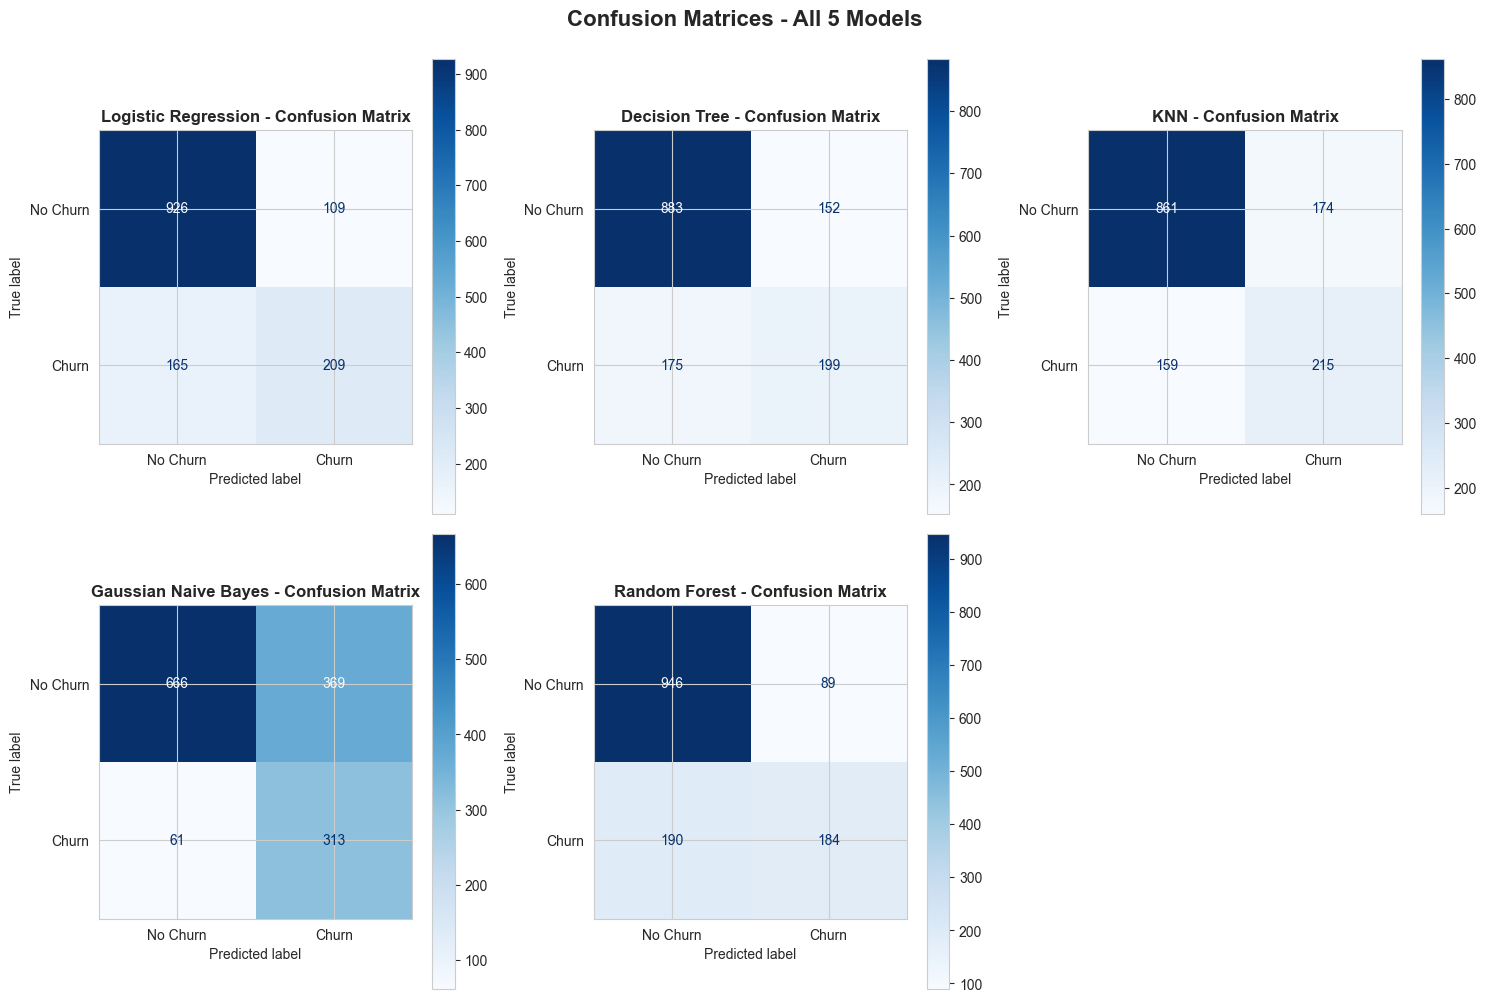


✓ Confusion matrices plotted and saved to results/confusion_matrices.png

----------------------------------------------------------------------

Logistic Regression:
  True Negatives:  926
  False Positives: 109
  False Negatives: 165
  True Positives:  209

Decision Tree:
  True Negatives:  883
  False Positives: 152
  False Negatives: 175
  True Positives:  199

KNN:
  True Negatives:  861
  False Positives: 174
  False Negatives: 159
  True Positives:  215

Gaussian Naive Bayes:
  True Negatives:  666
  False Positives: 369
  False Negatives: 61
  True Positives:  313

Random Forest:
  True Negatives:  946
  False Positives: 89
  False Negatives: 190
  True Positives:  184


In [14]:
# ====================================================================
# SECTION 14: CONFUSION MATRICES FOR ALL FIVE MODELS
# ====================================================================

print("\n" + "="*70)
print("CONFUSION MATRICES - ALL MODELS")
print("="*70)

# Create subplots for confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices - All 5 Models', fontsize=16, fontweight='bold', y=1.00)

# Model predictions for confusion matrices
models_cm = [
    ('Logistic Regression', y_pred_lr),
    ('Decision Tree', y_pred_dt),
    ('KNN', y_pred_knn),
    ('Gaussian Naive Bayes', y_pred_nb),
    ('Random Forest', y_pred_rf)
]

for idx, (model_name, y_pred) in enumerate(models_cm):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    plot_confusion_matrix(y_test, y_pred, model_name, ax=ax)

# Hide the extra subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confusion matrices plotted and saved to results/confusion_matrices.png")

# Print confusion matrices as text
print("\n" + "-"*70)
for model_name, y_pred in models_cm:
    print(f"\n{model_name}:")
    cm = confusion_matrix(y_test, y_pred)
    print(f"  True Negatives:  {cm[0, 0]}")
    print(f"  False Positives: {cm[0, 1]}")
    print(f"  False Negatives: {cm[1, 0]}")
    print(f"  True Positives:  {cm[1, 1]}")

## Section 14: Confusion Matrices for All Five Models


ROC CURVE COMPARISON


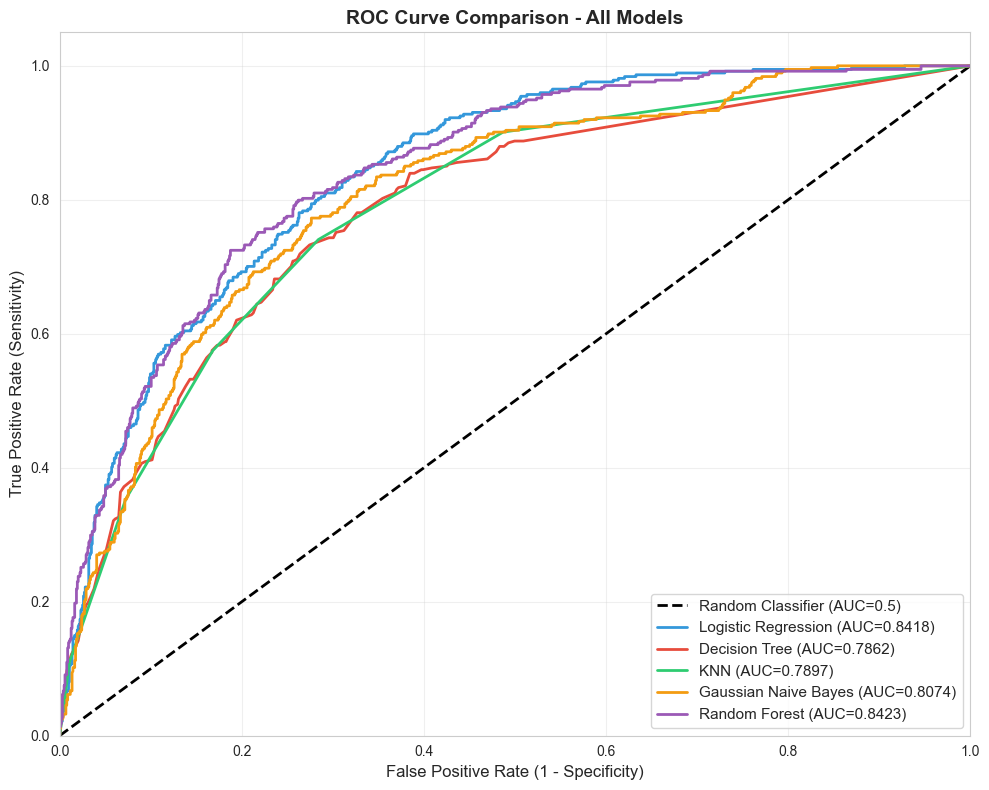


✓ ROC curve comparison plotted and saved to results/roc_curves.png

📝 Interpretation:
  - Higher and more to the left = Better model
  - AUC closer to 1.0 = Better discriminative ability
  - The random classifier has AUC = 0.5 (diagonal line)


In [15]:
# ====================================================================
# SECTION 15: ROC CURVE COMPARISON (SINGLE PLOT)
# ====================================================================

print("\n" + "="*70)
print("ROC CURVE COMPARISON")
print("="*70)

# Plot ROC curves for all models
fig, ax = plt.subplots(figsize=(10, 8))

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC=0.5)')

# Plot each model's ROC curve
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
for idx, (model_name, predictions) in enumerate(all_predictions.items()):
    y_proba = predictions['y_proba']
    
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    ax.plot(fpr, tpr, lw=2, color=colors[idx],
            label=f'{model_name} (AUC={roc_auc:.4f})')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve Comparison - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ ROC curve comparison plotted and saved to results/roc_curves.png")
print("\n📝 Interpretation:")
print("  - Higher and more to the left = Better model")
print("  - AUC closer to 1.0 = Better discriminative ability")
print("  - The random classifier has AUC = 0.5 (diagonal line)")

## Section 15: ROC Curve Comparison (Single Plot)

In [16]:
# ====================================================================
# SECTION 16: BEST MODEL SELECTION FROM ACTUAL METRICS
# ====================================================================

print("\n" + "="*70)
print("PROGRAMMATIC BEST MODEL SELECTION")
print("="*70)

# Selection strategy: AUC (threshold-independent, handles class imbalance)
best_model_idx = comparison_df['AUC'].idxmax()
best_model_auc = comparison_df.loc[best_model_idx, 'Model']
best_auc_score = comparison_df.loc[best_model_idx, 'AUC']

# Also show top 3 by AUC
print(f"\nTop 3 Models by AUC Score:")
top_3 = comparison_df.nlargest(3, 'AUC')[['Model', 'AUC', 'Recall']]
print(top_3.to_string(index=False))

print(f"\n🏆 WINNER: {best_model_auc}")
print(f"   AUC Score: {best_auc_score:.4f}")

# Show recall for all models (important for churn prediction)
print(f"\n📊 All Models Ranked by Recall (Churn Detection Rate):")
recall_ranking = comparison_df.nlargest(5, 'Recall')[['Model', 'Recall', 'Precision', 'AUC']]
print(recall_ranking.to_string(index=False))

print(f"\n💡 Selection Rationale:")
print(f"   AUC is used because:")
print(f"   - Independent of classification threshold")
print(f"   - Better for imbalanced datasets")
print(f"   - Evaluates discriminative power across all thresholds")
print(f"   - Complements recall for churn prediction")


PROGRAMMATIC BEST MODEL SELECTION

Top 3 Models by AUC Score:
               Model      AUC   Recall
       Random Forest 0.842323 0.491979
 Logistic Regression 0.841848 0.558824
Gaussian Naive Bayes 0.807419 0.836898

🏆 WINNER: Random Forest
   AUC Score: 0.8423

📊 All Models Ranked by Recall (Churn Detection Rate):
               Model   Recall  Precision      AUC
Gaussian Naive Bayes 0.836898   0.458944 0.807419
                 KNN 0.574866   0.552699 0.789735
 Logistic Regression 0.558824   0.657233 0.841848
       Decision Tree 0.532086   0.566952 0.786198
       Random Forest 0.491979   0.673993 0.842323

💡 Selection Rationale:
   AUC is used because:
   - Independent of classification threshold
   - Better for imbalanced datasets
   - Evaluates discriminative power across all thresholds
   - Complements recall for churn prediction


## Section 16: Best Model Selection from Actual Metrics


FEATURE IMPORTANCE ANALYSIS

✓ Total features after preprocessing: 45


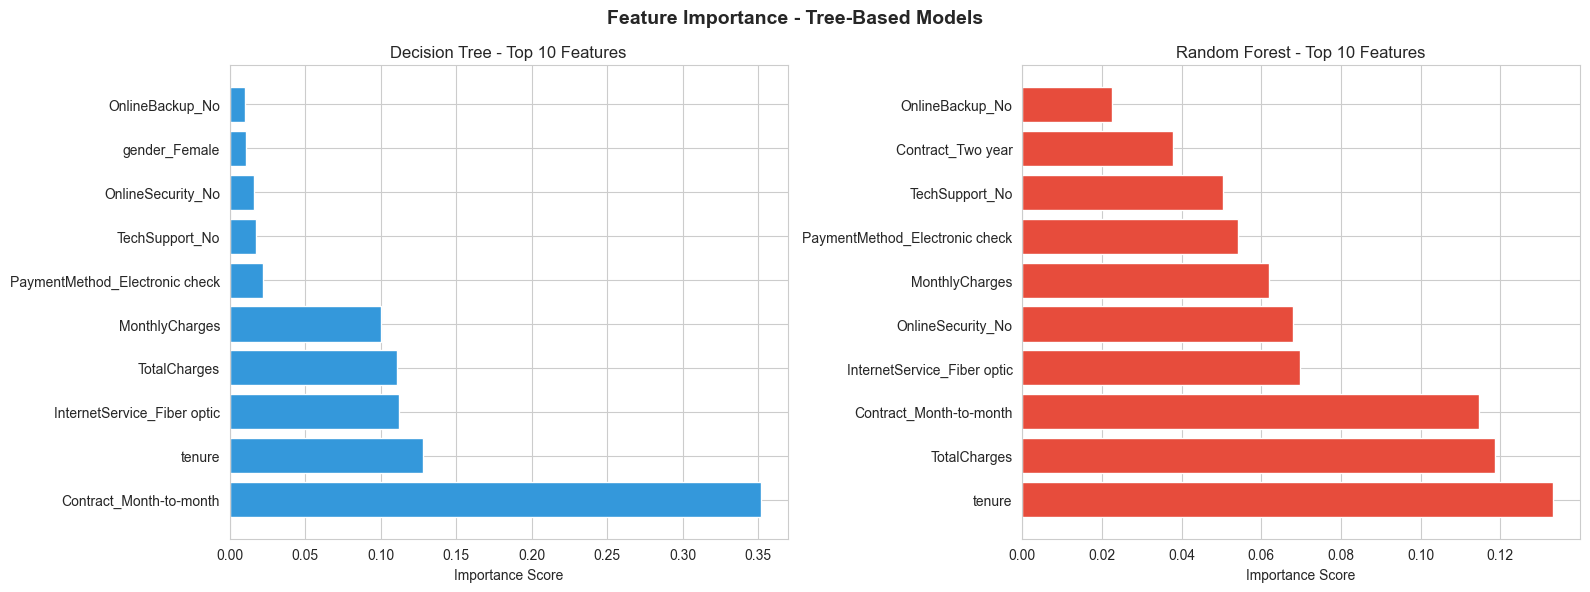


✓ Feature importance plots saved to results/feature_importance.png


In [17]:
# ====================================================================
# SECTION 17: OPTIONAL FEATURE IMPORTANCE (DECISION TREE, RANDOM FOREST)
# ====================================================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Extract feature names from preprocessor
feature_names = []

# Get numerical feature names (scaled)
feature_names.extend(numerical_features)

# Get categorical feature names (one-hot encoded)
# Get the encoder from the preprocessor
categorical_encoder = preprocessor.named_transformers_['categorical'].named_steps['encoder']
cat_feature_names = categorical_encoder.get_feature_names_out(categorical_features).tolist()
feature_names.extend(cat_feature_names)

print(f"\n✓ Total features after preprocessing: {len(feature_names)}")

# Get feature importances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance - Tree-Based Models', fontsize=14, fontweight='bold')

# Decision Tree
dt_model = dt_pipeline.named_steps['model']
dt_importances = dt_model.feature_importances_
dt_indices = np.argsort(dt_importances)[-10:]  # Top 10
axes[0].barh(range(len(dt_indices)), dt_importances[dt_indices], color='#3498db')
axes[0].set_yticks(range(len(dt_indices)))
axes[0].set_yticklabels([feature_names[i] if i < len(feature_names) else f'Feature {i}' 
                           for i in dt_indices], fontsize=10)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Decision Tree - Top 10 Features')
axes[0].invert_yaxis()

# Random Forest
rf_model = rf_pipeline.named_steps['model']
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[-10:]  # Top 10
axes[1].barh(range(len(rf_indices)), rf_importances[rf_indices], color='#e74c3c')
axes[1].set_yticks(range(len(rf_indices)))
axes[1].set_yticklabels([feature_names[i] if i < len(feature_names) else f'Feature {i}' 
                          for i in rf_indices], fontsize=10)
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Random Forest - Top 10 Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance plots saved to results/feature_importance.png")

## Section 17: Optional Feature Importance (Decision Tree, Random Forest)

In [18]:
# ====================================================================
# SECTION 18: EXPORT TEST SPLIT FOR STREAMLIT (test_data.csv)
# ====================================================================

print("\n" + "="*70)
print("SAVING TEST DATA FOR STREAMLIT APPLICATION")
print("="*70)

# Combine X_test with y_test for test_data.csv
test_data = X_test.copy()
test_data['Churn'] = y_test.values

# Save to CSV
test_csv_path = DATA_DIR / 'test_data.csv'
test_data.to_csv(test_csv_path, index=False)

print(f"\n✓ Test data saved to: {test_csv_path}")
print(f"  Shape: {test_data.shape}")
print(f"  Includes 'Churn' column for evaluation metrics")
print(f"  Ready for Streamlit app demonstration")

# Save comparison DataFrame to CSV
results_csv_path = RESULTS_DIR / 'model_comparison.csv'
comparison_df.to_csv(results_csv_path, index=False)
print(f"\n✓ Model comparison saved to: {results_csv_path}")


SAVING TEST DATA FOR STREAMLIT APPLICATION

✓ Test data saved to: C:\ml assignment\telco-customer-churn\data\test_data.csv
  Shape: (1409, 20)
  Includes 'Churn' column for evaluation metrics
  Ready for Streamlit app demonstration

✓ Model comparison saved to: C:\ml assignment\telco-customer-churn\results\model_comparison.csv


## Section 18: Export Test Split for Streamlit (`test_data.csv`)

In [21]:
# ====================================================================
# SECTION 19: PERSIST TRAINED PIPELINES WITH JOBLIB
# ====================================================================

print("\n" + "="*70)
print("SAVING TRAINED MODELS WITH JOBLIB")
print("="*70)

# Save all trained pipelines (includes preprocessing)
pipelines = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree': dt_pipeline,
    'KNN': knn_pipeline,
    'Gaussian Naive Bayes': nb_pipeline,
    'Random Forest': rf_pipeline
}

for model_name, pipeline in pipelines.items():
    model_filename = model_name.lower().replace(" ", "_")
    pipeline_path = MODEL_DIR / f'{model_filename}_pipeline.pkl'
    joblib.dump(pipeline, pipeline_path)
    print(f"✓ Saved: {model_name}")
    print(f"  Path: {pipeline_path}")

# Also save the preprocessor separately for reference
preprocessor_path = MODEL_DIR / 'preprocessor.pkl'
joblib.dump(preprocessor, preprocessor_path)
print(f"\n✓ Saved: Preprocessor (standalone)")
print(f"  Path: {preprocessor_path}")

print(f"\n✓ All models include preprocessing pipelines")
print(f"  Streamlit can load and use directly without reimplementing preprocessing")
print(f"  This ensures consistency between training and deployment")


SAVING TRAINED MODELS WITH JOBLIB
✓ Saved: Logistic Regression
  Path: C:\ml assignment\telco-customer-churn\model\logistic_regression_pipeline.pkl
✓ Saved: Decision Tree
  Path: C:\ml assignment\telco-customer-churn\model\decision_tree_pipeline.pkl
✓ Saved: KNN
  Path: C:\ml assignment\telco-customer-churn\model\knn_pipeline.pkl
✓ Saved: Gaussian Naive Bayes
  Path: C:\ml assignment\telco-customer-churn\model\gaussian_naive_bayes_pipeline.pkl
✓ Saved: Random Forest
  Path: C:\ml assignment\telco-customer-churn\model\random_forest_pipeline.pkl

✓ Saved: Preprocessor (standalone)
  Path: C:\ml assignment\telco-customer-churn\model\preprocessor.pkl

✓ All models include preprocessing pipelines
  Streamlit can load and use directly without reimplementing preprocessing
  This ensures consistency between training and deployment


## Section 19: Persist Trained Pipelines with Joblib

In [ ]:
# ====================================================================
# SECTION 20: OBSERVATION TEMPLATE GENERATED FROM ACTUAL RESULTS
# ====================================================================

print("\n" + "="*70)
print("MODEL OBSERVATIONS TEMPLATE")
print("="*70)
print("\n📝 Use the actual metrics below to write observations for README.md")
print("   Complete each section with insights from the results above.\n")

observation_template = """
## Model Observations

| ML Model Name | Observation about model performance |
|---|---|
| Logistic Regression | Based on metrics: Accuracy={lr_acc}, AUC={lr_auc}, Precision={lr_prec}, Recall={lr_rec}, F1={lr_f1}, MCC={lr_mcc} - [Complete with analysis] |
| Decision Tree | Based on metrics: Accuracy={dt_acc}, AUC={dt_auc}, Precision={dt_prec}, Recall={dt_rec}, F1={dt_f1}, MCC={dt_mcc} - [Complete with analysis] |
| KNN | Based on metrics: Accuracy={knn_acc}, AUC={knn_auc}, Precision={knn_prec}, Recall={knn_rec}, F1={knn_f1}, MCC={knn_mcc} - [Complete with analysis] |
| Naive Bayes | Based on metrics: Accuracy={nb_acc}, AUC={nb_auc}, Precision={nb_prec}, Recall={nb_rec}, F1={nb_f1}, MCC={nb_mcc} - [Complete with analysis] |
| Random Forest | Based on metrics: Accuracy={rf_acc}, AUC={rf_auc}, Precision={rf_prec}, Recall={rf_rec}, F1={rf_f1}, MCC={rf_mcc} - [Complete with analysis] |
| Overall Winner | {best_model_auc} (AUC={best_auc_score}) - [Complete with justification] |
"""

# Format the AUC score before inserting into template
best_auc_score_formatted = f"{best_model_auc:.4f}"

# Populate template with actual values
template_filled = observation_template.format(
    lr_acc=comparison_df.loc[0, 'Accuracy'], lr_auc=comparison_df.loc[0, 'AUC'],
    lr_prec=comparison_df.loc[0, 'Precision'], lr_rec=comparison_df.loc[0, 'Recall'],
    lr_f1=comparison_df.loc[0, 'F1'], lr_mcc=comparison_df.loc[0, 'MCC'],
    
    dt_acc=comparison_df.loc[1, 'Accuracy'], dt_auc=comparison_df.loc[1, 'AUC'],
    dt_prec=comparison_df.loc[1, 'Precision'], dt_rec=comparison_df.loc[1, 'Recall'],
    dt_f1=comparison_df.loc[1, 'F1'], dt_mcc=comparison_df.loc[1, 'MCC'],
    
    knn_acc=comparison_df.loc[2, 'Accuracy'], knn_auc=comparison_df.loc[2, 'AUC'],
    knn_prec=comparison_df.loc[2, 'Precision'], knn_rec=comparison_df.loc[2, 'Recall'],
    knn_f1=comparison_df.loc[2, 'F1'], knn_mcc=comparison_df.loc[2, 'MCC'],
    
    nb_acc=comparison_df.loc[3, 'Accuracy'], nb_auc=comparison_df.loc[3, 'AUC'],
    nb_prec=comparison_df.loc[3, 'Precision'], nb_rec=comparison_df.loc[3, 'Recall'],
    nb_f1=comparison_df.loc[3, 'F1'], nb_mcc=comparison_df.loc[3, 'MCC'],
    
    rf_acc=comparison_df.loc[4, 'Accuracy'], rf_auc=comparison_df.loc[4, 'AUC'],
    rf_prec=comparison_df.loc[4, 'Precision'], rf_rec=comparison_df.loc[4, 'Recall'],
    rf_f1=comparison_df.loc[4, 'F1'], rf_mcc=comparison_df.loc[4, 'MCC'],
    
    best_model_auc=best_model_name,
    best_auc_score=best_auc_score_formatted
)

print(template_filled)

print("\n" + "="*70)
print("KEY POINTS FOR OBSERVATIONS:")
print("="*70)
print("""
1. ACCURACY: Overall correctness (but watch for class imbalance!)
2. AUC: Threshold-independent discrimination ability
3. PRECISION: When model predicts churn, how often is it correct?
4. RECALL: Of actual churners, how many does model catch? ⭐ CRITICAL for business
5. F1: Balance between precision and recall
6. MCC: Correlation coefficient (considers all confusion matrix elements)

For CHURN PREDICTION specifically, focus on:
- HIGH RECALL (identify churners before they leave)
- Reasonable precision (minimize wasted retention offers)
- High AUC (good discrimination across thresholds)
""")

print("\n✓ Analysis Complete!")
print("  - 5 models trained and evaluated")
print("  - 6 metrics calculated per model")
print("  - Visualizations saved to results/")
print("  - Models saved to model/")
print("  - Test data exported for Streamlit app")


MODEL OBSERVATIONS TEMPLATE

📝 Use the actual metrics below to write observations for README.md
   Complete each section with insights from the results above.



ValueError: Unknown format code 'f' for object of type 'str'

## Section 20: Observation Template Generated from Actual Results